In [29]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%pwd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'/projectnb/batmanlab/mragoza/lung-project/notebooks/copdgene'

In [30]:
import sys, os
import pandas as pd

def add_path(p: str):
    if p not in sys.path:
        sys.path.append(p)

add_path(os.environ['LP_ROOT'])
add_path(os.environ['PROJECT'])

import project
from project.core.utils import pprint

import torch
torch.cuda.is_available()

True

# Gather examples

In [31]:
from pathlib import Path
#data_root = Path(os.environ['LP_ROOT'] / 'data' / 'COPDGene'
data_root = Path(os.environ['PRIVATE']) / 'data' / 'COPDGene'
for p in data_root.iterdir():
    print(p)

/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed
/restricted/projectnb/batmanlab/mragoza/data/COPDGene/sample1000_2025-07-22.txt
/restricted/projectnb/batmanlab/mragoza/data/COPDGene/sample1000_2025-07-22.csv
/restricted/projectnb/batmanlab/mragoza/data/COPDGene/subject_files.txt
/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Images
/restricted/projectnb/batmanlab/mragoza/data/COPDGene/sample1000_2025-07-17.csv
/restricted/projectnb/batmanlab/mragoza/data/COPDGene/DISK_USAGE
/restricted/projectnb/batmanlab/mragoza/data/COPDGene/ClinicalData


In [32]:
subject_file = data_root / 'sample1000_2025-07-22.csv'
subject_list = list(pd.read_csv(subject_file, sep='\t').sid)
subject_list

['16514P',
 '20748Q',
 '11007Z',
 '14771Z',
 '13651K',
 '15900P',
 '15312Y',
 '21042H',
 '21877G',
 '10127E',
 '23577E',
 '13816Q',
 '21559S',
 '25335Q',
 '23023N',
 '10572Z',
 '10887Y',
 '21410K',
 '17920F',
 '14684E',
 '16132B',
 '17862R',
 '11746L',
 '25728J',
 '20609C',
 '16637F',
 '13297S',
 '25767T',
 '25695U',
 '21572K',
 '15078Q',
 '15297C',
 '14857J',
 '13460D',
 '18840M',
 '12506W',
 '11498S',
 '21611U',
 '15088T',
 '12831H',
 '19612E',
 '19784H',
 '10217F',
 '23037Y',
 '25130Y',
 '15623P',
 '19027T',
 '14380K',
 '10212V',
 '16060C',
 '19356M',
 '22357L',
 '25923H',
 '21189L',
 '24608U',
 '15204V',
 '11743F',
 '11879E',
 '12477P',
 '10815Z',
 '17790S',
 '15489L',
 '11850G',
 '13034M',
 '17255W',
 '14632L',
 '26066U',
 '18184E',
 '15532M',
 '19558Y',
 '20640W',
 '21741H',
 '18015H',
 '17137Q',
 '12422Q',
 '15699W',
 '21933Q',
 '18397V',
 '14550J',
 '20703U',
 '21004Z',
 '24581A',
 '24331D',
 '17505T',
 '15894U',
 '16977D',
 '18935X',
 '19410S',
 '18515B',
 '21399W',
 '21899Q',

In [33]:
config = project.core.fileio.load_config('2026-08-08_config.yaml')
config['dataset']['root'] = str(data_root)
config['dataset']['examples']['subjects'] = subject_list
config['dataset']['examples']['state_pairs'] = [('EXP', 'INSP')]
config['dataset']['examples']['pipeline_tags']['forward_simulation'] = 'linear'
pprint(config['dataset'], 4, 10)

Loading 2026-08-08_config.yaml
dict(len=3)
├── 'name':     'COPDGene'
├── 'root':     '/restricted/projectnb/batmanlab/mragoza/data/COPDGene'
└── 'examples': dict(len=4)
    ├── 'subjects':      list(len=1000)
    |   ├── 0: '16514P'
    |   ├── 1: '20748Q'
    |   ├── 2: '11007Z'
    |   ├── 3: '14771Z'
    |   ├── 4: '13651K'
    |   ├── 5: '15900P'
    |   ├── 6: '15312Y'
    |   ├── 7: '21042H'
    |   ├── 8: '21877G'
    |   ├── 9: '10127E'
    |   └── <990 more items>
    ├── 'state_pairs':   list(len=1)
    |   └── 0: tuple(len=2)
    |       ├── 0: 'EXP'
    |       └── 1: 'INSP'
    ├── 'variant':       '2026-08-08'
    └── 'pipeline_tags': dict(len=8)
        ├── 'image_resampling':    'iso'
        ├── 'image_segmentation':  'tsvf'
        ├── 'image_registration':  'ugil'
        ├── 'anatomical_regions':  'lung'
        ├── 'material_properties': 'bela'
        ├── 'mesh_generation':     'pyg'
        ├── 'mesh_interpolation':  'int'
        └── 'forward_simulation':  'lin

In [34]:
examples = project.api.get_examples(config['dataset'])
len(examples)

Gathering examples


1000

# Visualize source images

In [35]:
# select example
ex = examples[0]
pprint(ex, max_depth=2)

Example()
├── dataset:  'COPDGene'
├── subject:  '16514P'
├── variant:  '2026-08-08'
├── paths:    dict(len=13)
|   ├── 'ref_state':       dict(len=2)
|   ├── 'init_state':      dict(len=5)
|   ├── 'curr_state':      dict(len=5)
|   ├── 'anatomical_map':  PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/masks/16514P_EXP_iso_tsvf_lung.nii.gz')
|   ├── 'anatomical_mesh': PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/meshes/16514P_EXP_iso_tsvf_lung_pyg.xdmf')
|   ├── 'material_map':    PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_EXP_iso_tsvf_bela_label.nii.gz')
|   ├── 'material_dir':    PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_EXP_iso_tsvf_bela')
|   ├── 'disp_field':      PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/

In [36]:
import numpy as np

# load source images
img0 = project.core.fileio.load_nibabel(ex.paths['init_state']['source_image'])
img1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['source_image'])

spacing0 = tuple(float(d) for d in img0.affine[:3,:3] @ np.ones(3))
spacing1 = tuple(float(d) for d in img1.affine[:3,:3] @ np.ones(3))

print(spacing0)
print(spacing1)
print(img0.affine)

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_EXP_STD_TEM_COPD.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.nii.gz
(-0.71875, 0.71875, 0.5)
(-0.71875, 0.71875, 0.7000007629394531)
[[  -0.71875    -0.          0.        167.640625]
 [   0.          0.71875     0.         -6.640625]
 [   0.          0.          0.5      -319.      ]
 [   0.          0.          0.          1.      ]]


In [37]:
import project.visual.matplotlib as mpl_viz

img_kws = dict(cmap='gray', vmin=-1000, vmax=-500)

In [38]:
mpl_viz.SliceViewer(img0.get_fdata(), vox_spacing=spacing0, ax_height=4, ax_width=5, **img_kws)

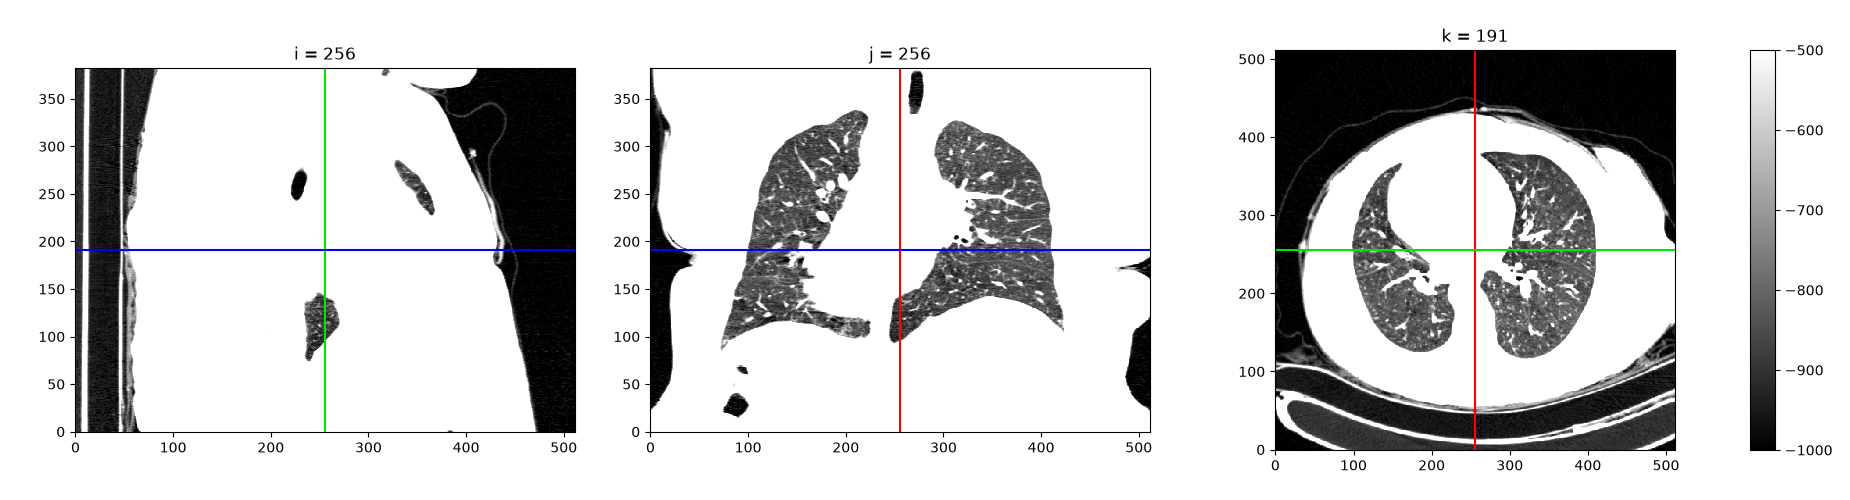

In [39]:
mpl_viz.SliceViewer(img1.get_fdata(), vox_spacing=spacing1, ax_height=4, ax_width=5,  **img_kws)

# Preprocessing tests

In [40]:
proc_config = {
    'image_resampling': {
        'spacing': (1.0, 1.0, 1.0),
        'interpolation': 'linear',
        'default_value': -1000.
    },
    'image_segmentation': {
        'tasks': [
            {
                'method': 'HU_threshold',
                'kwargs': {
                    'thresholds': {
                        'lt-950': {'type': 'absolute', 'operator': '<', 'value': -950},
                        'lt-910': {'type': 'absolute', 'operator': '<', 'value': -910},
                        'lt-850': {'type': 'absolute', 'operator': '<', 'value': -850},
                        'gt-500': {'type': 'absolute', 'operator': '>', 'value': -500},
                        'gt-200': {'type': 'absolute', 'operator': '>', 'value': -200},
                    }
                }
            },
            {
                'method': 'TotalSegmentator',
                'kwargs': {
                    'task': 'total',
                    'roi_subset': [
                        'lung_upper_lobe_right',
                        'lung_middle_lobe_right',
                        'lung_lower_lobe_right',
                        'lung_upper_lobe_left',
                        'lung_lower_lobe_left',
                    ]
                }
            },
            {
                'method': 'TotalSegmentator',
                'kwargs': {'task': 'lung_vessels'}
            },
            {
                'method': 'VisionFeature',
                'kwargs': {
                    'model': 'vista3d',
                    'results_dir': '/restricted/projectnb/batmanlab/haozhe/Lung_Mesh_Segment/data/nnUNetv2/nnUNet_results',
                }
            },
        ]
    },
    'image_registration': {
        'method': 'unigradicon',
        'kwargs': {
            'model': 'gradiconlung',
            'io_sim': 'lncc2',
            'io_iterations': 50,
            'sigma': 1,
            'loss_function_masking': True,
            'intensity_conservation_loss': True,
            'weights_root': '/restricted/projectnb/batmanlab/mragoza/lung-project/network_weights'
        }
    },
    'anatomical_regions': {
        'roi_order': [
            'lung_upper_lobe_right',
            'lung_middle_lobe_right',
            'lung_lower_lobe_right',
            'lung_upper_lobe_left',
            'lung_lower_lobe_left',
        ],
        'region_filter': {
            'min_voxels': 30,
            'keep_largest': True
        }
    },
    'material_properties': {
        'density': {
            'default': 1000.,
            'terms': {
                'image':  {'weight': 1.0}
            },
            'range': [1., 2000.]
        },
        'youngs_modulus': {
            'default': 2000.,
            'terms': {
                #'lung_arteries': {'weight': +3000.}, #  5000
                #'lung_veins':    {'weight': +3000.}, #  5000
                #'lung_airways':  {'weight': +6000.}, #  8000
                'lt-850':        {'weight': -1000.}, #  1000
                'lt-910':        {'weight':  -500.}, #   500
                'lt-950':        {'weight':  -250.}, #   250
                'ggo':           {'weight': +2000.}, #  4000
                'consolidation': {'weight': +4000.}, #  8000
                'nodule':        {'weight': +8000.}, # 16000 
            },
            'range': [1., 20000.]
        },
        'poisson_ratio': {
            'default': 0.42
        }
    },
    'mesh_generation': {
        'use_affine_spacing': True,
        'mesh_parameters': {
            'max_facet_distance': 0.75,
            'max_cell_circumradius': 5.0,
            'lloyd': True,
            'odt': True
        }
    },
    'mesh_interpolation': {
        'displacement_key': 'u_reg',
        'interpolate_args': {}
    },
    'forward_simulation': {
        'physics_adapter': {},
        'pde_solver': {
            '_class': 'warp',
            'g_vector': [0., -9.81, 0.]
        },
        'boundary_condition': {
            'type': 'mesh_key', 'value': 'u_reg'
        },
        'output_key': 'u_fwd'
    }
}

In [41]:
pprint(config['preprocessing'], max_depth=3)

dict(len=8)
├── 'image_resampling':    dict(len=3)
|   ├── 'spacing':       list(len=3)
|   |   ├── 0: 1.0
|   |   ├── 1: 1.0
|   |   └── 2: 1.0
|   ├── 'interpolation': 'linear'
|   └── 'default_value': -1000.0
├── 'image_segmentation':  dict(len=1)
|   └── 'tasks': list(len=4)
|       ├── 0: dict(len=2)
|       ├── 1: dict(len=2)
|       ├── 2: dict(len=2)
|       └── 3: dict(len=2)
├── 'image_registration':  dict(len=2)
|   ├── 'method': 'unigradicon'
|   └── 'kwargs': dict(len=7)
|       ├── 'model':                       'gradiconlung'
|       ├── 'io_sim':                      'lncc2'
|       ├── 'io_iterations':               50
|       ├── 'sigma':                       1
|       ├── 'loss_function_masking':       True
|       ├── 'intensity_conservation_loss': True
|       └── 'weights_root':                '/projectnb/batmanlab/mragoza/lung-project/network_weights'
├── 'anatomical_regions':  dict(len=2)
|   ├── 'roi_order':     list(len=5)
|   |   ├── 0: 'lung_upper_lobe_righ

In [42]:
%autoreload
from project.preprocessing.api import preprocess_example

for ex in [ex]:
    preprocess_example(ex, config['preprocessing'])

print('Done')

INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/images/16514P_EXP_iso.nii.gz exists; Skipping stage resample_image_spacing
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/masks/16514P_EXP_iso_tsvf_domain.nii.gz exists; Skipping stage create_segmentation_masks
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/images/16514P_INSP_iso.nii.gz exists; Skipping stage resample_image_spacing
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/masks/16514P_INSP_iso_tsvf_domain.nii.gz exists; Skipping stage create_segmentation_masks
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_EXP_iso_tsvf_ugil_INSP.nii.gz exists; Skipping stage estimate_displacement_field
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/masks/16514P_EXP_iso_tsvf_lung.nii.gz exists; S

In [43]:
import numpy as np

ex = examples[0]
img0 = project.core.fileio.load_nibabel(ex.paths['init_state']['resampled_image'])
img1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['resampled_image'])
anat = project.core.fileio.load_nibabel(ex.paths['anatomical_map'])
mat = project.core.fileio.load_nibabel(ex.paths['material_map'])
m = anat.get_fdata() > 0

spacing0 = tuple(float(d) for d in img0.affine[:3,:3] @ np.ones(3))
print(spacing0)

spacing1 = tuple(float(d) for d in img1.affine[:3,:3] @ np.ones(3))
print(spacing1)

img0.affine

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/images/16514P_EXP_iso.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/images/16514P_INSP_iso.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/masks/16514P_EXP_iso_tsvf_lung.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_EXP_iso_tsvf_bela_label.nii.gz
(-1.0, 1.0, 1.0)
(-1.0, 1.0, 1.0)


array([[  -1.       ,   -0.       ,    0.       ,  167.5      ],
       [  -0.       ,    1.       ,   -0.       ,   -6.5      ],
       [   0.       ,    0.       ,    1.       , -318.3001709],
       [   0.       ,    0.       ,    0.       ,    1.       ]])

In [44]:
img_kws = dict(cmap='gray', vmin=-1024, vmax=-256)

cmap = mpl_viz.get_label_cmap(n_labels=10, select=None, include_bg=True)
mask_kws = dict(cmap=cmap, vmin=0, vmax=10)

disp_kws = dict(cmap='seismic', vmin=-20, vmax=20)

In [45]:
mpl_viz.SliceViewer(img0.get_fdata() * m, vox_spacing=spacing0, ax_height=4, ax_width=5, **img_kws)

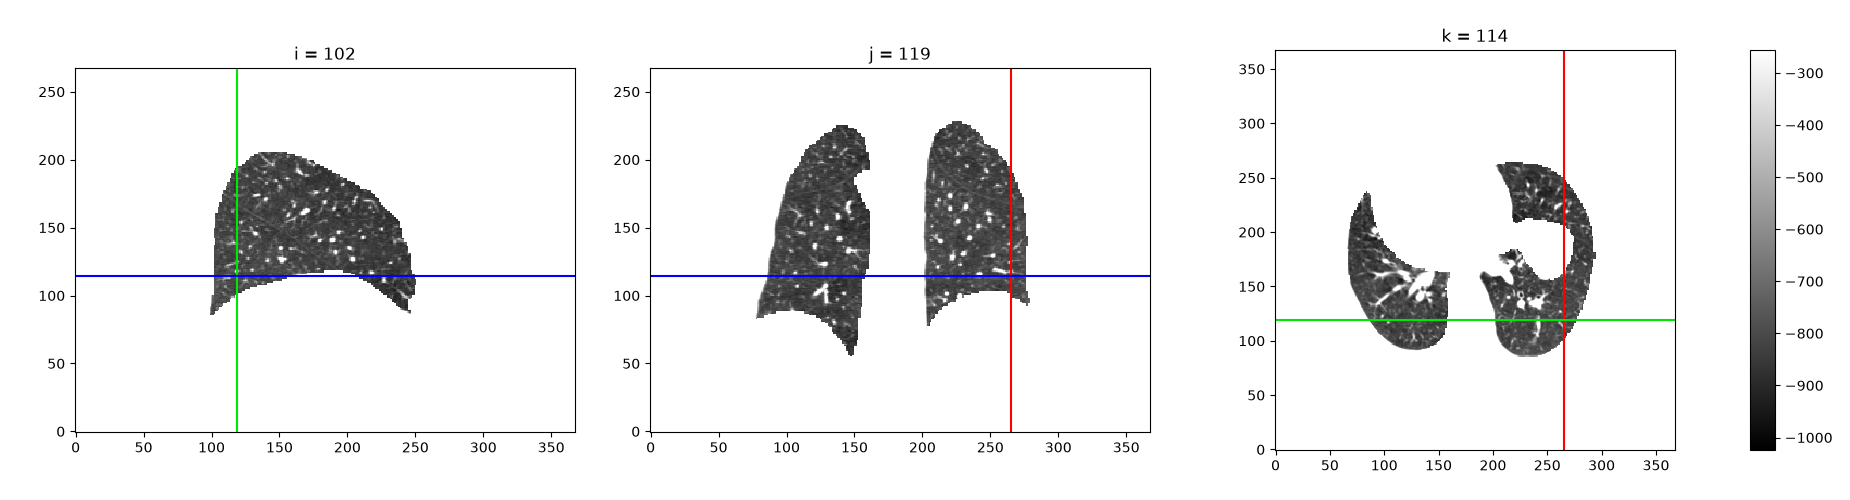

In [46]:
mpl_viz.SliceViewer(img1.get_fdata() * m, index=(102,119,114), vox_spacing=spacing0, ax_height=4, ax_width=5, **img_kws)

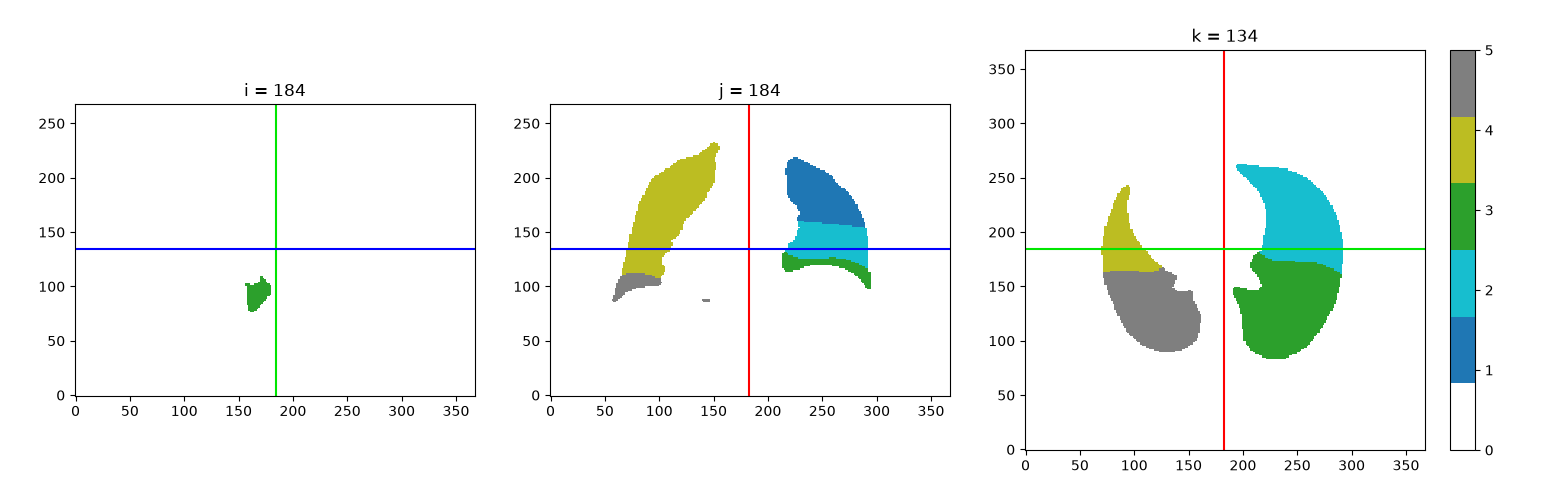

In [47]:
cmap = mpl_viz.get_label_cmap(5, include_bg=True)

mpl_viz.SliceViewer(anat.get_fdata(), vox_spacing=spacing0, ax_height=4, ax_width=4, cmap=cmap, clim=(0, 5))

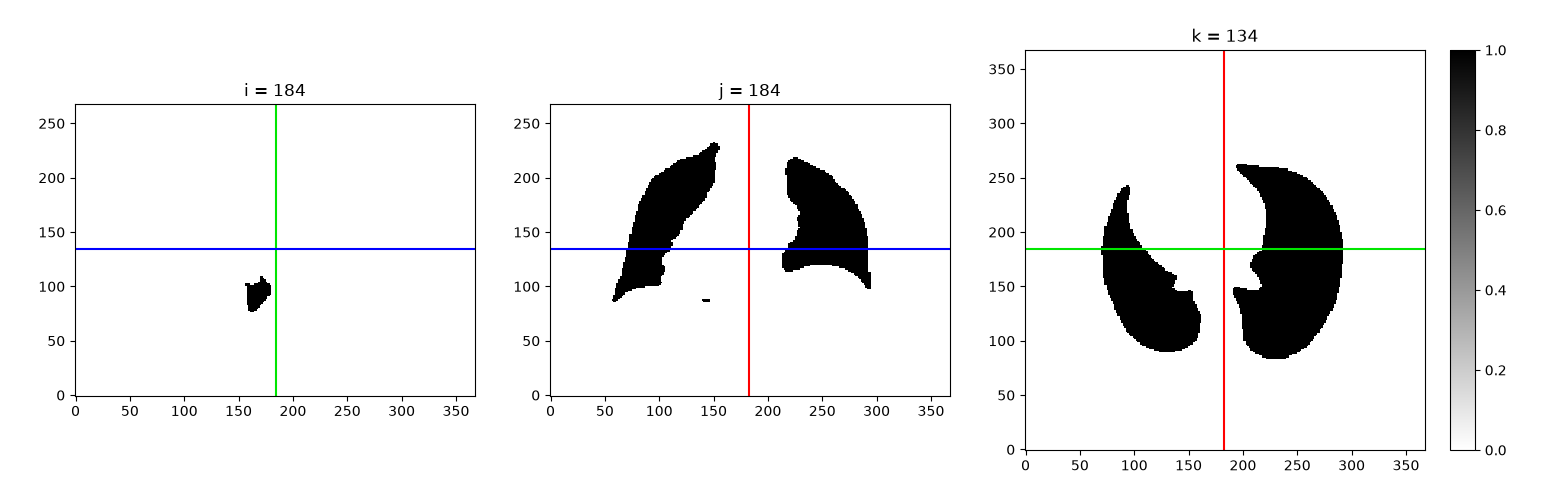

In [48]:
mpl_viz.SliceViewer(mat.get_fdata(), vox_spacing=spacing0, ax_height=4, ax_width=4, cmap='binary')

-910 0.003914573321301407
-850 0.03489864967273626
-500 0.8736531120951175
-200 0.9667802238031614


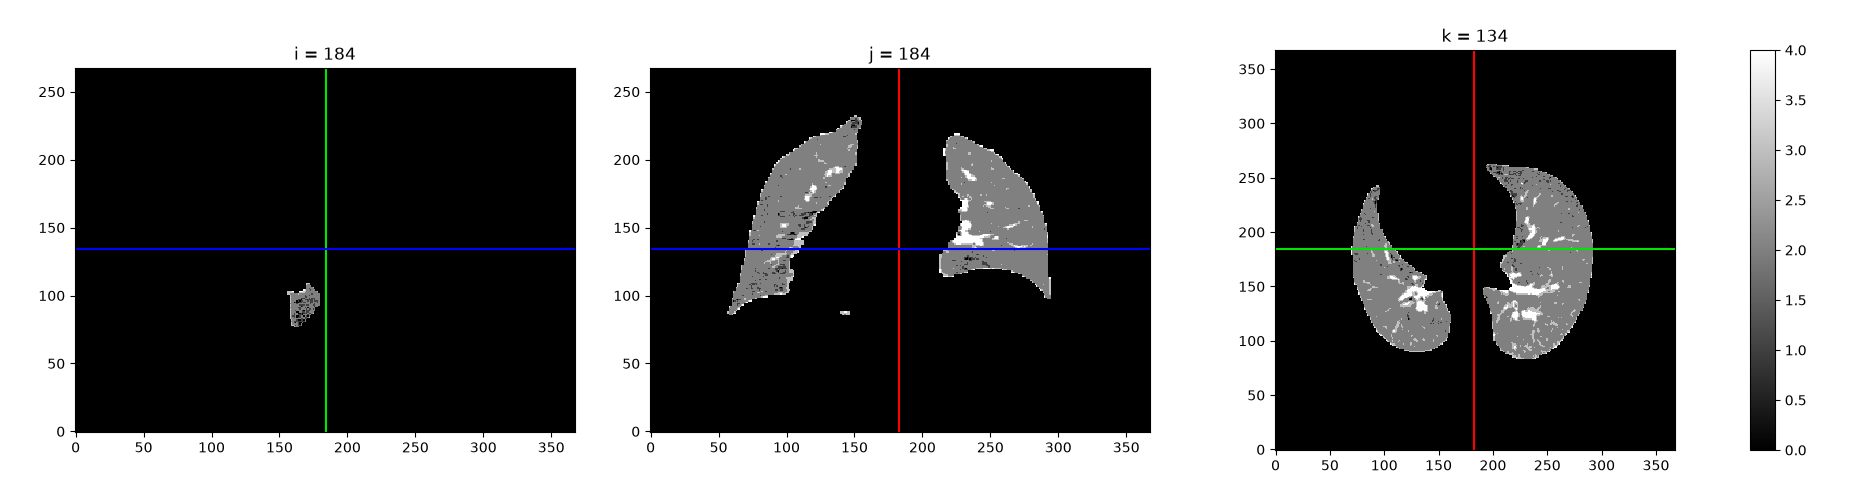

In [49]:
I = img0.get_fdata()

bins = [-910, -850, -500, -200]
#bins = np.percentile(I[m], [5, 25, 75, 95])

for b in bins:
    p = (I[m] < b).mean()
    print(b, p)

T = np.digitize(I, bins)

mpl_viz.SliceViewer(T * m, vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='gray', clim=(0, len(bins)))

In [50]:
E = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'youngs_modulus.nii.gz')
nu = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'poisson_ratio.nii.gz')
rho = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'density.nii.gz')

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_EXP_iso_tsvf_bela/youngs_modulus.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_EXP_iso_tsvf_bela/poisson_ratio.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_EXP_iso_tsvf_bela/density.nii.gz


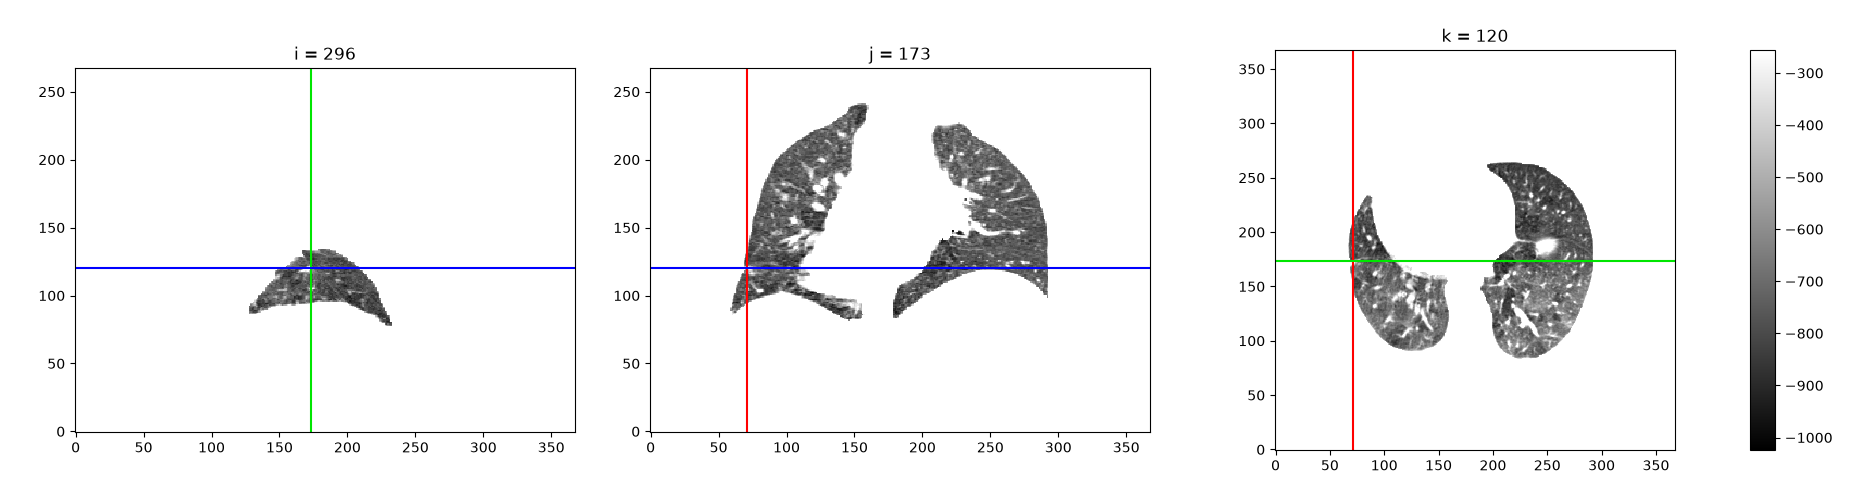

In [51]:
mpl_viz.SliceViewer(img0.get_fdata() * m, index=(296,173, 120), vox_spacing=spacing0, ax_height=4, ax_width=5, **img_kws)

In [52]:
mpl_viz.SliceViewer(E.get_fdata() * m, vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='jet', clim=(0, 2e4))

/projectnb/batmanlab/mragoza/lung-project/project/visual/matplotlib.py:307: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(


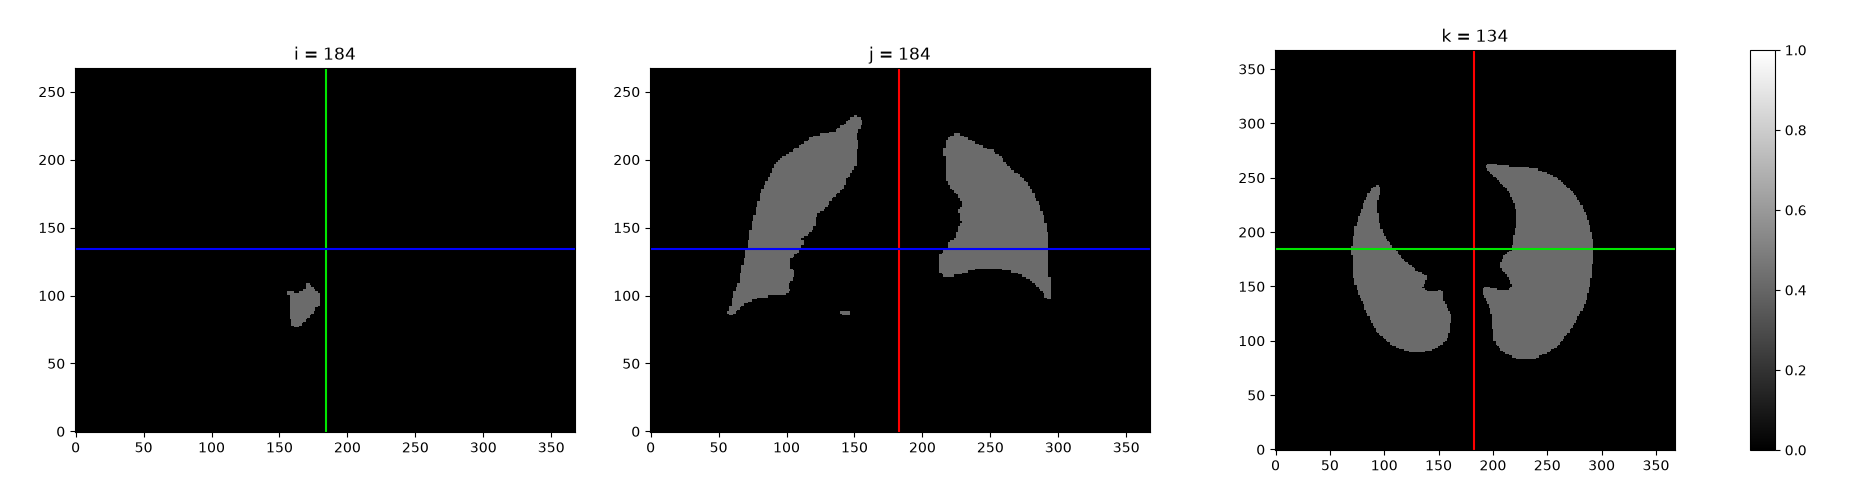

In [53]:
mpl_viz.SliceViewer(nu.get_fdata() * m, vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='gray', clim=(0, 1))

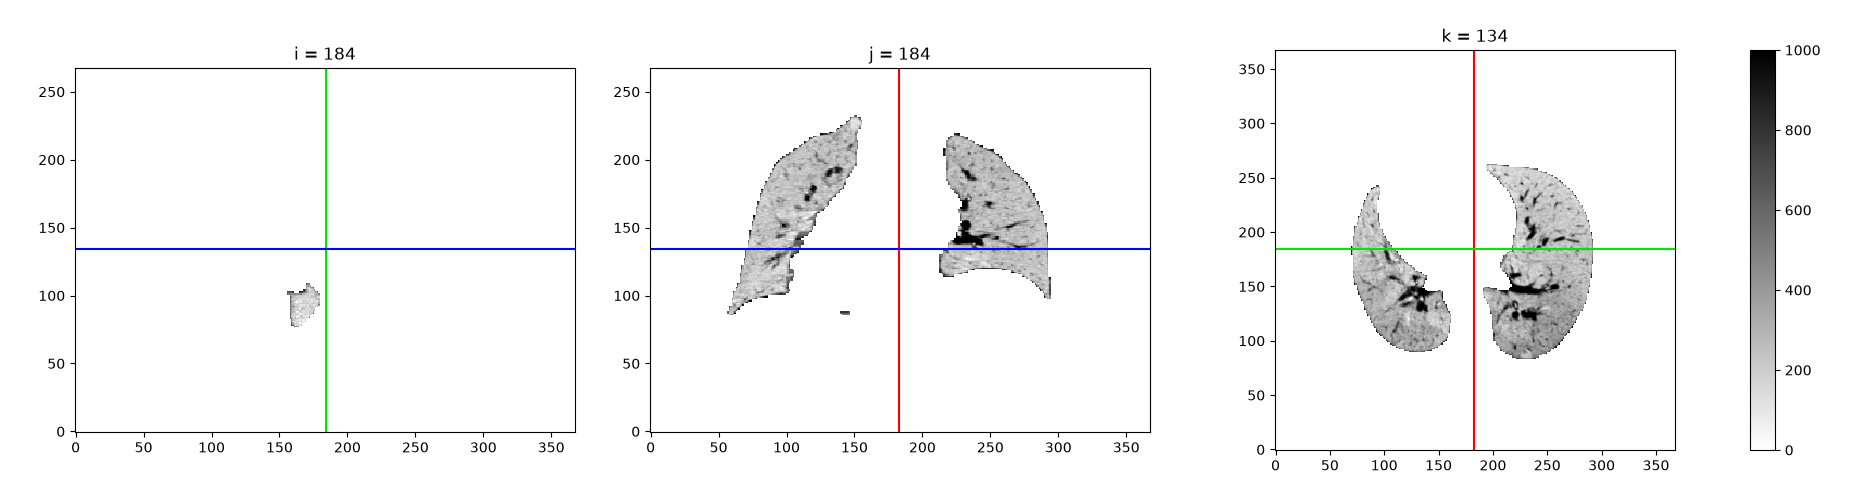

In [54]:
mpl_viz.SliceViewer(rho.get_fdata() * m, vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='binary', clim=(0, 1000))

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_EXP_iso_tsvf_ugil_INSP.nii.gz


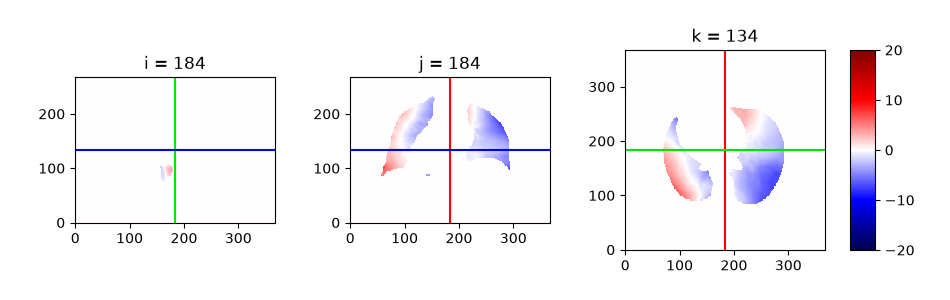

In [55]:
disp_path = str(ex.paths['disp_field'])
disp = project.core.fileio.load_nibabel(disp_path).get_fdata()

mpl_viz.SliceViewer(disp[...,0] * m, vox_spacing=spacing0, **disp_kws)
#mpl_viz.SliceViewer(disp[...,1] * m, vox_spacing=spacing0, **disp_kws)
#mpl_viz.SliceViewer(disp[...,2] * m, vox_spacing=spacing0, **disp_kws)

In [56]:
import project.visual.pyvista as pv_viz

mesh = project.core.fileio.load_meshio(ex.paths['forward_mesh'])
mesh

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/meshes/16514P_EXP_iso_tsvf_ugil_INSP_lung_pyg_bela_int_linear.xdmf


<meshio mesh object>
  Number of points: 23303
  Number of cells:
    tetra: 99240
  Point data: medit:ref, image, u_reg, E, nu, rho, u_fwd
  Cell data: medit:ref, region, image, u_reg, E, nu, rho, u_fwd

2026-08-20 19:16:13.800 (4822.298s) [    145BC1E66400]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


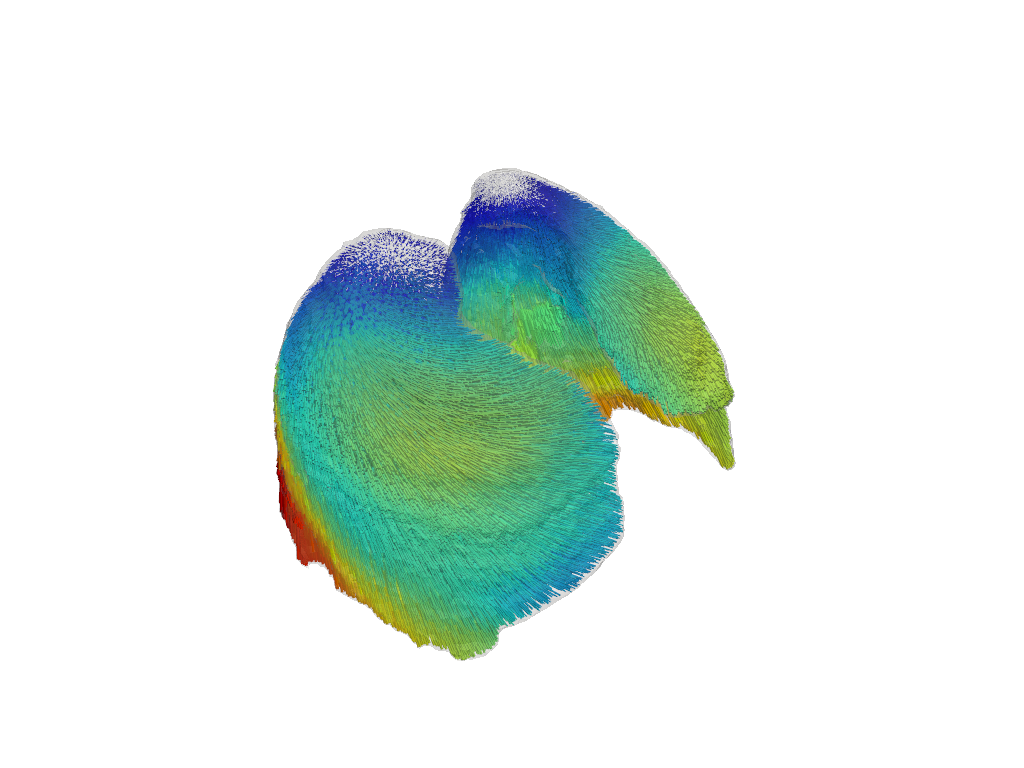

In [57]:
def show_mesh(mesh, key):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter()
    p.add_mesh(m, show_scalar_bar=False, color='white', opacity=0.2)
    g = m.glyph(scale=key, orient=key, factor=1.0)
    p.add_mesh(g, show_scalar_bar=False, cmap='jet')
    p.show(jupyter_backend='static')

show_mesh(mesh, key='u_fwd')

# Optimization

In [58]:
import math

opt_config = {
    'targets': ['E', 'nu'],
    'param_specs': {
        'E': {'mode': 'log10', 'mean': 3.0, 'std': 0.1},
        'nu': {'mode': 'logit', 'min': 0.0, 'max': 0.5},
    },
    'physics_adapter': {},
    'pde_solver': {
        '_class': 'warp',
        'material_type': 'linear',
        'relative_loss': True,
        'tv_reg_weight': 1e-4, #0.001,
        'newton_steps': 100,
        'newton_alpha': 1.0,
        'newton_beta': math.sqrt(0.5),
        'newton_rtol': 1e-5,
        'cg_maxiter': 0, #100,
        'cg_rtol': 1e-5, #1e-4,
        'verbose': False
    },
    'optimizer': {
        '_class': 'Adam',
        'lr': 0.1,
        'global_steps': 10,
        'local_steps': 100,
        'tol': 1e-3
    },
    'initialize': {
        'num_restarts': 1,
        'noise_std': 0.1
    },
    'boundary_condition': {
        'type': 'mesh_key',
        'value': 'u_reg'
    }
}

In [59]:
%autoreload
import project.optimization
project.optimization.simulate_example(ex, opt_config)

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/images/16514P_EXP_iso.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/masks/16514P_EXP_iso_tsvf_domain.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/meshes/16514P_EXP_iso_tsvf_ugil_INSP_lung_pyg_bela_int_linear.xdmf
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_EXP_iso_tsvf_bela_label.nii.gz
Targets: ['E', 'nu']
Warp 1.15.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA A40" (44 GiB, sm_86, mempool enabled)
   Kernel cache:
     /usr2/collab/mragoza/.cache/warp/1.15.0
MeshField()
├── cells: Tensor(shape=torch.Size([99240, 3]), dtype=torch.float32, device=cpu)
|   ├── 0: Tensor(shape=torch.Size([3]), dtype=torch.float32, device=cpu)
|   ├── 1: Tensor(shape=torch.Size([3]), dtype=

In [60]:
outputs = {}
outputs['linear'] = project.core.paths.RunOutputs(stage='opt_linear')
outputs['stvk'] = project.core.paths.RunOutputs(stage='opt_stvk')
outputs['nh'] = project.core.paths.RunOutputs(stage='opt_nh')

In [61]:
project.core.fileio.load_meshio(ex.paths['target_mesh'])

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/meshes/16514P_EXP_iso_tsvf_ugil_INSP_lung_pyg_bela_int_linear.xdmf


<meshio mesh object>
  Number of points: 23303
  Number of cells:
    tetra: 99240
  Point data: medit:ref, image, u_reg, E, nu, rho, u_fwd
  Cell data: medit:ref, region, image, u_reg, E, nu, rho, u_fwd

In [45]:
%autoreload
import project.optimization
project.optimization.optimize_example(ex, opt_config, outputs['linear'])

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/images/16514P_EXP_iso.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/masks/16514P_EXP_iso_tsvf_domain.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/meshes/16514P_EXP_iso_tsvf_ugil_INSP_lung_pyg_bela_int_linear.xdmf
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_EXP_iso_tsvf_bela_label.nii.gz
Targets: ['E', 'nu']
Start optimization
Trial 1/1
Global optimization
Iteration 1 loss=6.6593e-03 (nan) grad=8.2904e-06 (1.0000e+00) norm=2.5020e+01 (nan)
Iteration 2 loss=6.5560e-03 (1.5521e-02) grad=7.5913e-06 (9.1567e-01) norm=3.3389e+01 (5.1015e-01)
Iteration 3 loss=6.4623e-03 (1.4292e-02) grad=6.9554e-06 (8.3897e-01) norm=4.3789e+01 (3.7770e-01)
Iteration 4 loss=6.3774e-03 (1.3130e-02) grad=6.3781e-06 (7.6934e-01) norm=5.4954e+01 (2.8395e-01)
Iterati

Material is nearly incompressible (K/G = 112.73287963867188)


Iteration 52 loss=4.9708e-04 (1.5673e-02) grad=4.3991e-06 (6.1416e-02) norm=3.0548e+02 (1.2333e-02)


Material is nearly incompressible (K/G = 129.00172424316406)


Iteration 53 loss=4.8939e-04 (1.5478e-02) grad=4.1608e-06 (5.8090e-02) norm=3.0687e+02 (1.2046e-02)


...

Iteration 99 loss=3.0246e-04 (7.3371e-03) grad=1.7763e-06 (2.4800e-02) norm=3.4735e+02 (5.9939e-03)


Material is nearly incompressible (K/G = 4076.754638671875)


Iteration 100 loss=3.0032e-04 (7.0871e-03) grad=1.8448e-06 (2.5756e-02) norm=3.4797e+02 (5.8900e-03)


Material is nearly incompressible (K/G = 4106.6962890625)
Material is nearly incompressible (K/G = 4106.6962890625)


Final loss: 0.0002981347788590938
dict(len=14)
├── 'volume':   Tensor(shape=torch.Size([99240]), dtype=torch.float32, device=cpu)
|   ├── 0: torch.float32(5.0935e-09)
|   ├── 1: torch.float32(1.4880e-08)
|   ├── 2: torch.float32(5.7120e-09)
|   ├── 3: torch.float32(7.4920e-09)
|   ├── 4: torch.float32(3.5784e-08)
|   ├── 5: torch.float32(2.1604e-08)
|   ├── 6: torch.float32(2.9759e-08)
|   ├── 7: torch.float32(5.4585e-09)
|   ├── 8: torch.float32(2.8810e-08)
|   ├── 9: torch.float32(2.5311e-08)
|   └── <99230 more items>
├── 'u_pred':   MeshField()
|   ├── cells: Tensor(shape=torch.Size([99240, 3]), dtype=torch.float32, device=cpu)
|   └── nodes: Tensor(shape=torch.Size([23303, 3]), dtype=torch.float32, device=cpu)
├── 'mu_pred':  MeshField()
|   ├── cells: Tensor(shape=torch.Size([99240]), dtype=torch.float32, device=cpu)
|   └── nodes: Tensor(shape=torch.Size([23303]), dtype=torch.float32, device=cpu)
├── 'lam_pred': MeshField()
|   ├── cells: Tensor(shape=torch.Size([99240]), dtype=

In [64]:
import project.visual.matplotlib as mpl_viz

def E_nu_from_G_K(G, K):
    E = 9*K*G / (3*K + G)
    nu = (3*K - 2*G)/(6*K + 2*G)
    return E, nu

raster_dir = outputs['linear'].raster_dir(ex)
E_lin = project.core.fileio.load_nibabel(raster_dir / 'E_pred.nii.gz').get_fdata()
nu_lin = project.core.fileio.load_nibabel(raster_dir / 'nu_pred.nii.gz').get_fdata()

Loading outputs/opt_linear/16514P/rasters/E_pred.nii.gz
Loading outputs/opt_linear/16514P/rasters/nu_pred.nii.gz


E_true


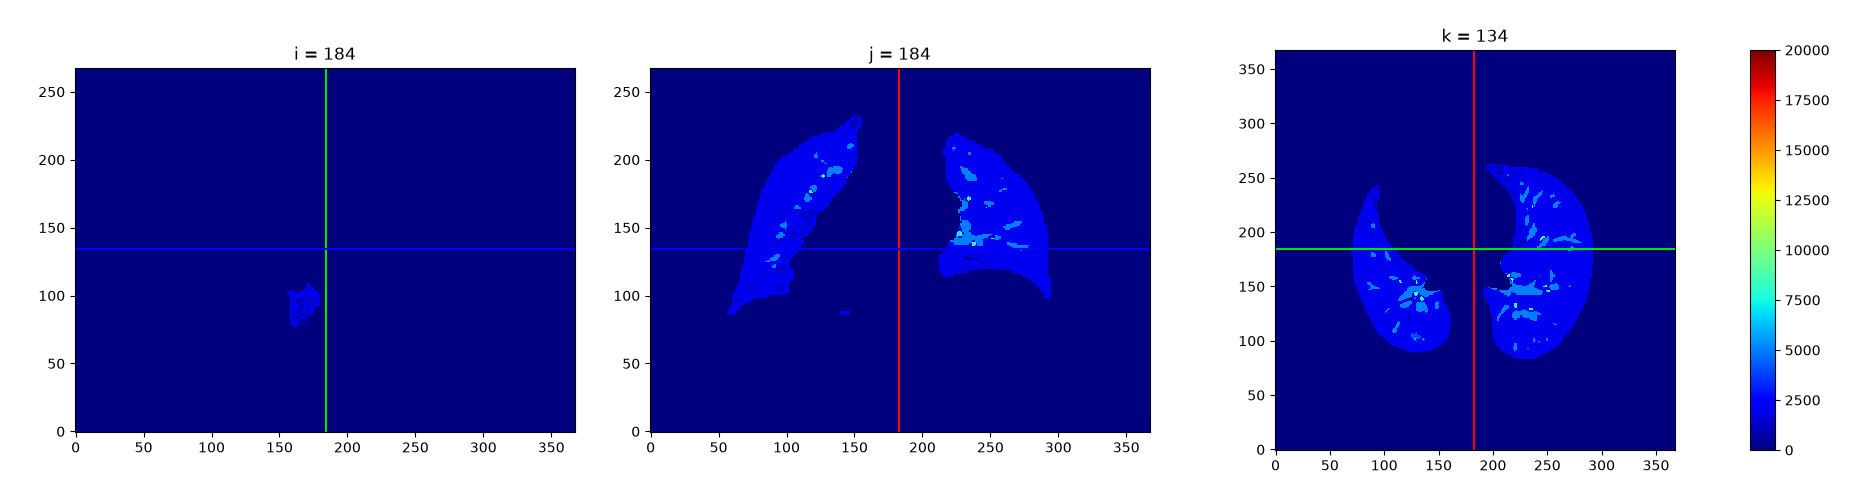

In [65]:
print('E_true')
mpl_viz.SliceViewer(E.get_fdata() * m, vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='jet', clim=(0, 2e4))

E - Linear


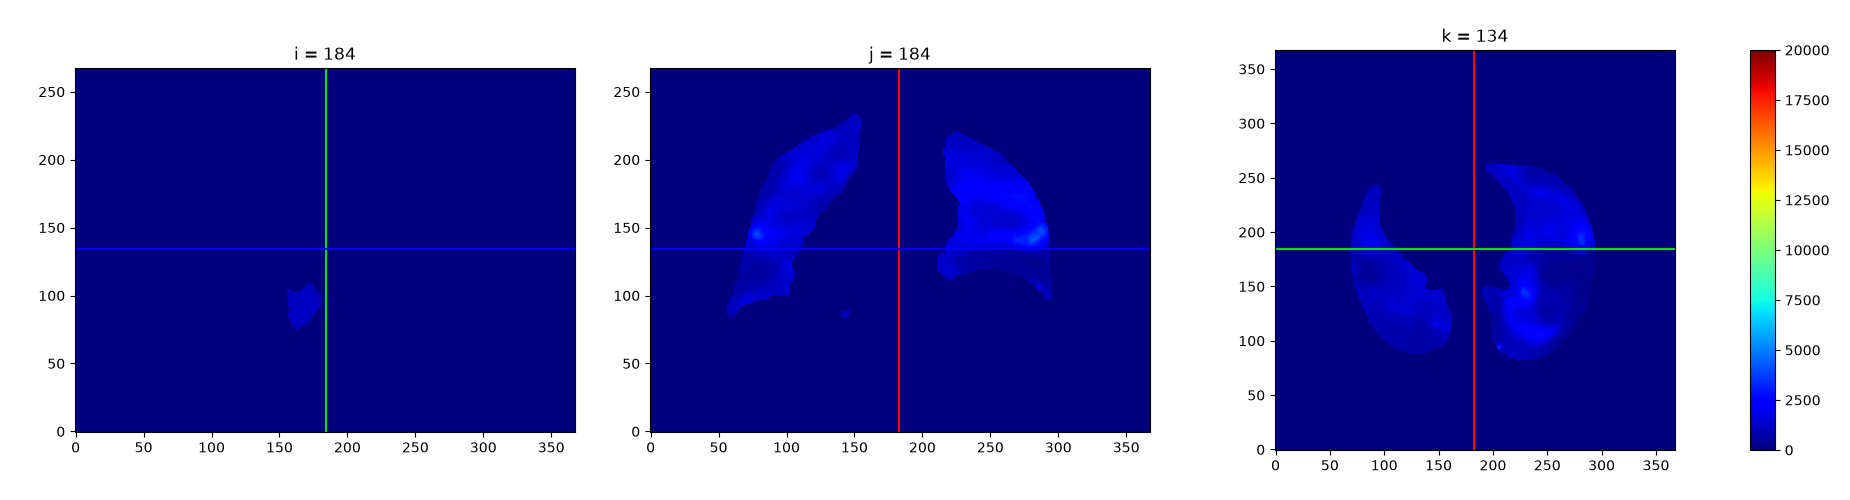

In [66]:
print('E - Linear')
mpl_viz.SliceViewer(E_lin, vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='jet', clim=(0, 2e4))

nu - Linear


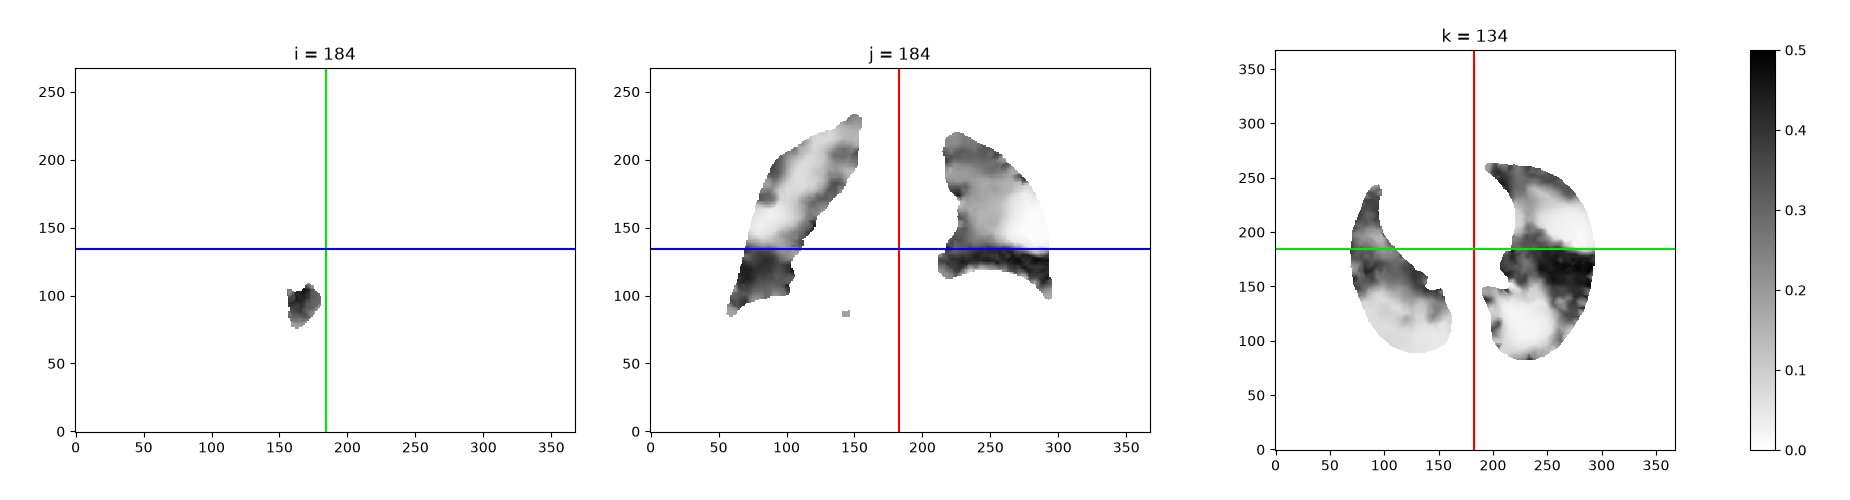

In [70]:
print('nu - Linear')
mpl_viz.SliceViewer(nu_lin, vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='binary', clim=(0.0, 0.5))

# High-quality visualizations

In [13]:
ex = examples[1]
pprint(ex)

Example()
├── dataset:  'COPDGene'
├── subject:  '16514P'
├── variant:  '2026-08-08'
├── paths:    dict(len=13)
|   ├── 'ref_state':       dict(len=2)
|   ├── 'init_state':      dict(len=5)
|   ├── 'curr_state':      dict(len=5)
|   ├── 'anatomical_map':  PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/masks/16514P_INSP_iso_tsvf_lung.nii.gz')
|   ├── 'anatomical_mesh': PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/meshes/16514P_INSP_iso_tsvf_lung_pyg.xdmf')
|   ├── 'material_map':    PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_INSP_iso_tsvf_bela_label.nii.gz')
|   ├── 'material_dir':    PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_INSP_iso_tsvf_bela')
|   ├── 'disp_field':      PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fie

In [14]:
img0 = project.core.fileio.load_nibabel(ex.paths['init_state']['resampled_image'])
img1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['resampled_image'])
anat = project.core.fileio.load_nibabel(ex.paths['anatomical_map'])
m = anat.get_fdata() > 0

E = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'youngs_modulus.nii.gz')
nu = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'poisson_ratio.nii.gz')
rho = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'density.nii.gz')

mesh = project.core.fileio.load_meshio(ex.paths['forward_mesh'])

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/images/16514P_INSP_iso.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/images/16514P_EXP_iso.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/masks/16514P_INSP_iso_tsvf_lung.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_INSP_iso_tsvf_bela/youngs_modulus.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_INSP_iso_tsvf_bela/poisson_ratio.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_INSP_iso_tsvf_bela/density.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/meshes/16514P_INSP_iso_tsvf_ugil_EXP_lung_pyg_bela_int_linear.xdmf


In [15]:
print(m.shape)
print(spacing0)
z = 134
c = 48

(368, 368, 268)
(-0.71875, 0.71875, 0.7000007629394531)


In [16]:
img_kws = dict(cmap='gray', vmin=-1000, vmax=-500)

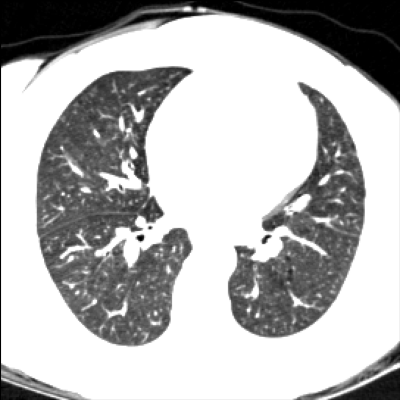

In [18]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(img0.get_fdata()[c:-c,c:-c,z].T, origin='lower', **img_kws)

In [19]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(img1.get_fdata()[c:-c,c:-c,z].T, origin='lower', **img_kws)

In [20]:
m = anat.get_fdata() > 0
E_m = E.get_fdata() * m
nu_m = nu.get_fdata() * m
rho_m = rho.get_fdata() * m

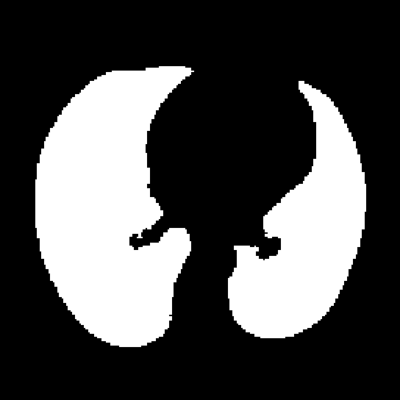

In [21]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(m[c:-c,c:-c,z].T, origin='lower', cmap='gray')

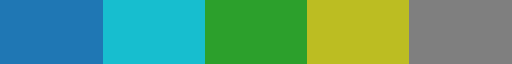

In [22]:
mpl_viz.get_label_cmap(5, include_bg=False)

In [23]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow((anat.get_fdata())[c:-c,c:-c,z].T, origin='lower', cmap=mpl_viz.get_label_cmap(5, include_bg=True))

In [24]:
import matplotlib.pyplot as plt

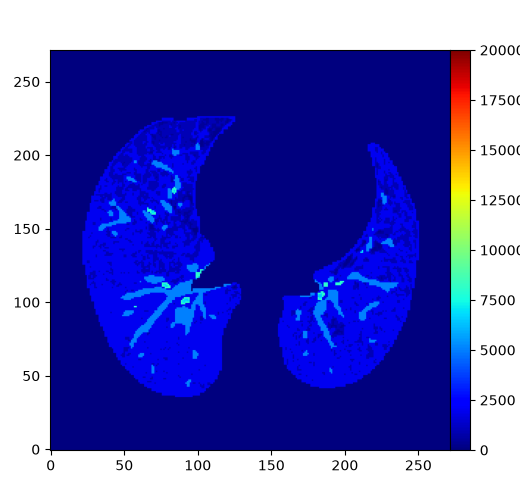

In [47]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(E_m[c:-c,c:-c,125].T, origin='lower', cmap='jet', clim=(0, 2e4))
plt.colorbar(im, cax)

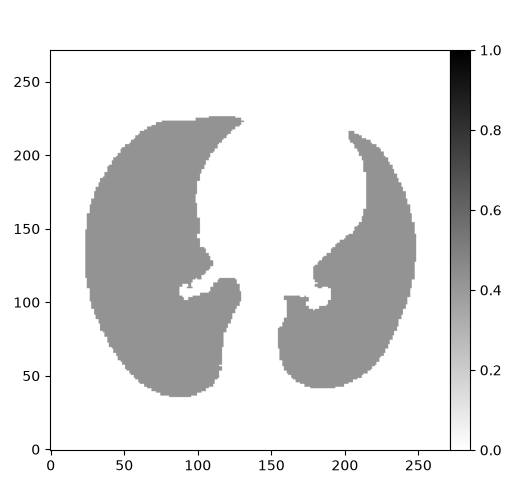

In [39]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(nu_m[c:-c,c:-c,z].T, origin='lower', cmap='binary', clim=(0, 1))
plt.colorbar(im, cax)

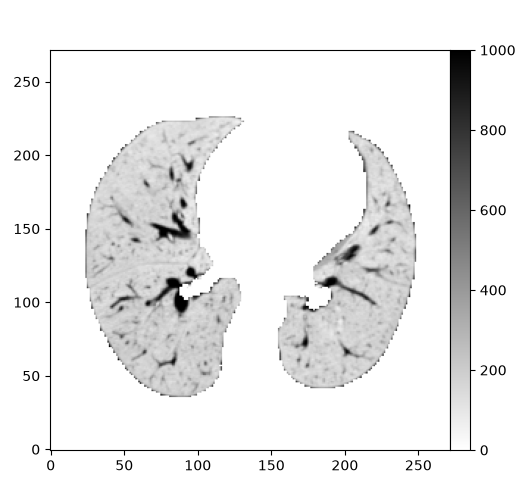

In [43]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(rho_m[c:-c,c:-c,z].T, origin='lower', cmap='binary', clim=(0, 1000))
plt.colorbar(im, cax)

In [40]:
mesh

<meshio mesh object>
  Number of points: 32008
  Number of cells:
    tetra: 142299
  Point data: medit:ref, image, u_reg, E, nu, rho, u_fwd
  Cell data: medit:ref, region, image, u_reg, E, nu, rho, u_fwd

In [41]:
np.unique(mesh.cell_data['region'])

array([1, 2, 3, 4, 5])

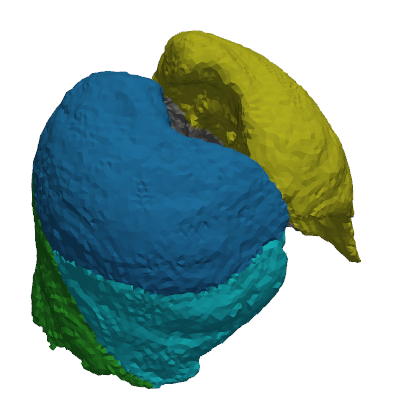

In [137]:
def show_mesh(mesh):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=(400,400))
    p.add_mesh(m, scalars='region', show_scalar_bar=False, clim=(1, 5), opacity=1.0, cmap=mpl_viz.get_label_cmap(5, include_bg=False))
    #g = m.glyph(scale=key, orient=key, factor=1.0)
    #p.add_mesh(g, show_scalar_bar=False, cmap='turbo', clim=(2,24))
    p.camera.zoom(1.4)
    p.show(jupyter_backend='static')

show_mesh(mesh)

In [158]:
vmax = np.percentile(np.linalg.norm(mesh.point_data['u_reg'], axis=1), 99)
vmax

np.float32(28.082287)

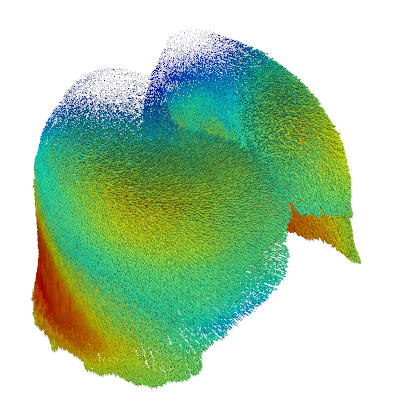

In [192]:
def plot_disp(mesh, key):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=(400,400))
    #p.add_mesh(m, scalars=key, show_scalar_bar=False)
    g = m.glyph(scale=key, orient=key, factor=0.5)
    p.add_mesh(g, show_scalar_bar=False, cmap='jet', clim=(0, vmax))
    p.camera.zoom(1.4)
    return p

p = plot_disp(mesh, key='u_reg')
p.show(jupyter_backend='static')

In [193]:
import pyvista as pv
surf = pv.wrap(mesh).extract_surface(algorithm='geometry')

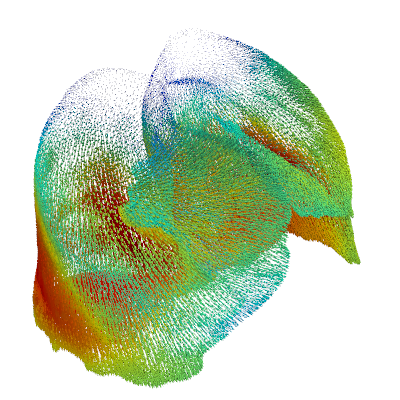

In [194]:
p = plot_disp(surf, key='u_reg')
p.show(jupyter_backend='static')

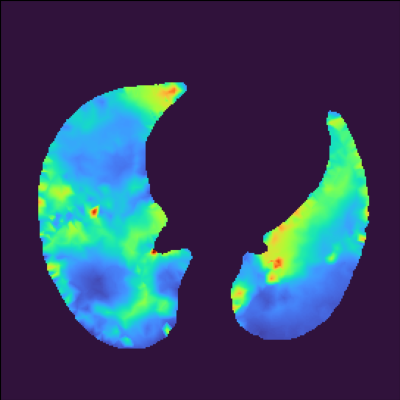

In [130]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(K_lin[c:-c,c:-c,z].T, origin='lower', cmap='turbo', clim=(0, 20000))

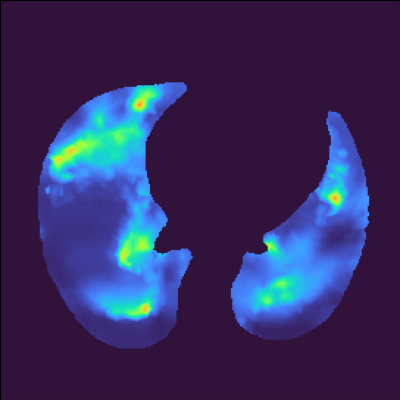

In [132]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(G_lin[c:-c,c:-c,z].T, origin='lower', cmap='turbo', clim=(0, 10000))

In [133]:
mesh = project.core.fileio.load_meshio('outputs/opt_linear/16514P/meshes/optimized.xdmf')
mesh

Loading outputs/opt_linear/16514P/meshes/optimized.xdmf


<meshio mesh object>
  Number of points: 23583
  Number of cells:
    tetra: 99939
  Point data: medit:ref, image, u_true, mu_pred, lam_pred, rho_pred, u_pred, residual
  Cell data: medit:ref, region, image, u_true, mu_pred, lam_pred, rho_pred, u_pred, residual

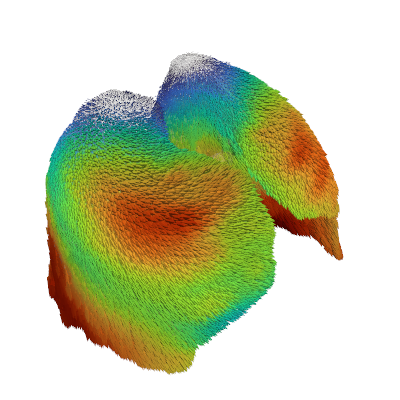

In [161]:
def show_mesh(mesh, key):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=(400,400))
    p.add_mesh(m, show_scalar_bar=False, color='white', opacity=0.2)
    g = m.glyph(scale=key, orient=key, factor=1.0)
    p.add_mesh(g, show_scalar_bar=False, cmap='turbo', clim=(2,24))
    p.camera.zoom(1.25)
    p.show(jupyter_backend='static')

show_mesh(mesh, key='u_true')

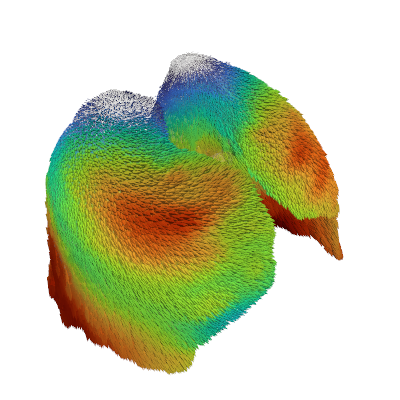

In [162]:
show_mesh(mesh, key='u_pred')

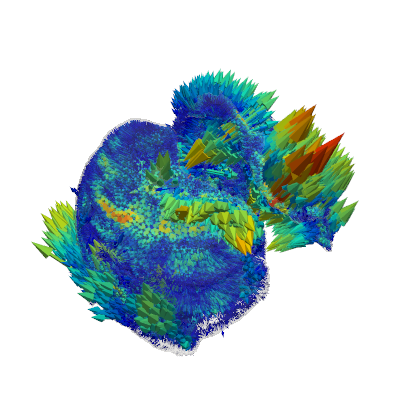

In [142]:
show_mesh(mesh, key='residual')